In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# fedavg
# df = pd.read_csv('/home1/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.04_23.22.30_fedavg/backdoor_tracking_log_nodefense.csv')
# flame
# df = pd.read_csv('/home1/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.04_23.24.42_flame/backdoor_tracking_log_nodefense.csv')
# krum
df = pd.read_csv('/home1/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.04_23.25.13_krum/backdoor_tracking_log_nodefense.csv')
# normbound
# df = pd.read_csv('/home1/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.04_23.25.29_normbound/backdoor_tracking_log_nodefense.csv')

# Create the plot
plt.figure(figsize=(12, 6))

# Plot each ASR column
plt.plot(df['iteration'], df['R1_ASR'], label='R1_ASR', marker='o', markersize=3)
plt.plot(df['iteration'], df['R2_ASR'], label='R2_ASR', marker='o', markersize=3)
plt.plot(df['iteration'], df['R3_ASR'], label='R3_ASR', marker='o', markersize=3)
plt.plot(df['iteration'], df['R4_ASR'], label='R4_ASR', marker='o', markersize=3)

# Add labels and title
plt.xlabel('Iteration')
plt.ylabel('ASR Value')
plt.title('ASR Values Across Iterations')
plt.legend()

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

# ---------------------------
# Small utilities
# ---------------------------

def get_region_colors():
    return {
        'R1': '#DAA520',  # Yellow
        'R2': '#EA6B66',  # Red
        'R3': '#2E8B57',  # Green
        'R4': '#1E90FF'   # Blue
    }

def parse_aggregation_rule(file_path: str) -> str:
    m = re.search(r'/([^/]+)/backdoor_tracking_log', file_path)
    return m.group(1) if m else "Unknown"

def load_and_prepare_df(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    # numeric coercion
    for i in range(1, 5):
        asr_col = f'R{i}_ASR'
        sel_col = f'R{i}_selected'
        if asr_col in df.columns:
            df[asr_col] = pd.to_numeric(df[asr_col], errors='coerce').fillna(0.0)
        if sel_col in df.columns:
            df[sel_col] = pd.to_numeric(df[sel_col], errors='coerce').fillna(0).astype(int)
    if 'acc' in df.columns:
        df['acc'] = pd.to_numeric(df['acc'], errors='coerce')
    # order by iteration
    if 'iteration' in df.columns:
        df = df.sort_values('iteration').reset_index(drop=True)
    else:
        df['iteration'] = range(len(df))
    return df

def compute_signed_delta_asr(df: pd.DataFrame) -> pd.DataFrame:
    """
    ΔASR_t = ASR_t - ASR_{t-1} for each region on rounds when that region is selected.
    For the first-ever time a region is selected, we use baseline 0 (so ΔASR = ASR_t - 0).
    """
    records = []
    seen = {f'R{i}': False for i in range(1, 5)}

    for t in range(len(df)):
        it = int(df.loc[t, 'iteration'])
        for i in range(1, 5):
            reg = f'R{i}'
            sel_col = f'{reg}_selected'
            asr_col = f'{reg}_ASR'
            if sel_col not in df.columns or asr_col not in df.columns:
                continue
            if df.loc[t, sel_col] == 1:
                cur = float(df.loc[t, asr_col])
                if not seen[reg]:
                    prev = 0.0
                    seen[reg] = True
                else:
                    prev = float(df.loc[t-1, asr_col]) if t > 0 else 0.0
                records.append({'Region': reg, 'Iteration': it, 'Delta_ASR': cur - prev})
    return pd.DataFrame(records)

def melt_asr_series(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return long-form ASR dataframe: Region, Iteration, ASR, Selected (0/1).
    """
    rows = []
    for t in range(len(df)):
        it = int(df.loc[t, 'iteration'])
        for i in range(1, 5):
            reg = f'R{i}'
            asr_col = f'{reg}_ASR'
            sel_col = f'{reg}_selected'
            if asr_col not in df.columns:
                continue
            asr = float(df.loc[t, asr_col])
            sel = int(df.loc[t, sel_col]) if sel_col in df.columns else 0
            rows.append({'Region': reg, 'Iteration': it, 'ASR': asr, 'Selected': sel})
    return pd.DataFrame(rows)

def compute_prev_attack_flags(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each region & iteration t, mark PrevAttacked=1 if that region was selected at t-1.
    """
    out = []
    for t in range(len(df)):
        it = int(df.loc[t, 'iteration'])
        for i in range(1, 5):
            reg = f'R{i}'
            asr_col = f'{reg}_ASR'
            sel_prev_col = f'{reg}_selected'
            if asr_col not in df.columns:
                continue
            asr_t = float(df.loc[t, asr_col])
            prev_attacked = 0
            if t > 0 and sel_prev_col in df.columns:
                prev_attacked = int(df.loc[t-1, sel_prev_col])
            out.append({'Region': reg, 'Iteration': it, 'ASR': asr_t, 'PrevAttacked': prev_attacked})
    return pd.DataFrame(out)


# ---------------------------
# Plots
# ---------------------------

def plot_delta_asr_over_iterations(delta_df: pd.DataFrame, out_path: Path, title_prefix: str):
    if delta_df.empty:
        return
    colors = get_region_colors()
    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=delta_df,
        x='Iteration',
        y='Delta_ASR',
        hue='Region',
        hue_order=['R1', 'R2', 'R3', 'R4'],
        palette=colors,
        marker='o'
    )
    plt.axhline(0.0, color='gray', linewidth=1, linestyle='--')
    plt.title(f'{title_prefix}: ΔASR Over Iterations (signed)')
    plt.xlabel('Iteration')
    plt.ylabel('ΔASR (signed)')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()

def compute_attack_flags_current(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for reg in ['R1', 'R2', 'R3', 'R4']:
        sel_col = f'{reg}_selected'
        for _, r in df[['iteration', sel_col]].iterrows():
            rows.append({'Region': reg, 'Iteration': r['iteration'], 'Attacked': int(r[sel_col])})
    return pd.DataFrame(rows)

def plot_acc_and_asr(df: pd.DataFrame, out_path: Path, title_prefix: str):
    if 'acc' not in df.columns or df['acc'].isna().all():
        return

    colors = get_region_colors()
    iters = df['iteration'].to_numpy()

    # melt ASR columns into long form
    asr_long = melt_asr_series(df)  # -> columns: Region, Iteration, ASR
    # attach "Attacked this iteration" flags
    cur_flags = compute_attack_flags_current(df)  # Region, Iteration, Attacked
    asr_long = asr_long.merge(cur_flags, on=['Region', 'Iteration'], how='left')

    fig, ax_acc = plt.subplots(figsize=(12, 6))
    ax_acc.plot(iters, df['acc'], label='Accuracy', marker='o', linewidth=2, color='black')
    ax_acc.set_xlabel('Iteration')
    ax_acc.set_ylabel('Accuracy', color='black')
    ax_acc.tick_params(axis='y', labelcolor='black')

    ax_asr = ax_acc.twinx()
    for reg in ['R1', 'R2', 'R3', 'R4']:
        sub = asr_long[asr_long['Region'] == reg]
        if sub.empty:
            continue
        ax_asr.plot(sub['Iteration'], sub['ASR'], label=f'{reg} ASR',
                    marker=None, linewidth=1.8, color=colors[reg], alpha=0.8)
        hi = sub[sub['Attacked'] == 1]
        ax_asr.scatter(hi['Iteration'], hi['ASR'],
                       label=f'{reg} (attacked this iter)',
                       color=colors[reg], marker='X', s=60, edgecolors='white', linewidths=0.8)

    ax_asr.set_ylabel('ASR', color='dimgray')  # note: values are 0–1 in your CSV
    ax_asr.tick_params(axis='y', labelcolor='dimgray')

    # de-duplicate legend entries
    handles, labels = [], []
    for ax in (ax_acc, ax_asr):
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh); labels.append(ll)
    plt.legend(handles, labels, loc='best', frameon=True)

    plt.title(f'{title_prefix}: Accuracy + ASR Over Iterations\n'
              "(X markers = region attacked in this iteration)")
    ax_acc.grid(True, axis='x', alpha=0.2); ax_acc.grid(True, axis='y', alpha=0.2)
    fig.tight_layout()
    fig.savefig(out_path)
    plt.close(fig)


def plot_box_delta_asr(delta_df: pd.DataFrame, out_path: Path, title_prefix: str):
    if delta_df.empty:
        return
    colors = get_region_colors()
    plt.figure(figsize=(8, 5))
    ax = sns.boxplot(
        data=delta_df,
        x='Region',
        y='Delta_ASR',
        order=['R1', 'R2', 'R3', 'R4'],
        palette=colors
    )
    # Explain boxplot in title/annotation
    plt.title(f'{title_prefix}: Distribution of ΔASR by Region\n'
              '(Box = IQR; center line = median; whiskers ≈ 1.5×IQR; circles = outliers)')
    plt.xlabel('Region'); plt.ylabel('ΔASR (signed)')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()

def plot_box_asr(asr_df: pd.DataFrame, out_path: Path, title_prefix: str, attacked_only: bool = False):
    if asr_df.empty:
        return
    colors = get_region_colors()
    data = asr_df.copy()
    if attacked_only:
        data = data[data['Selected'] == 1]
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=data,
        x='Region',
        y='ASR',
        order=['R1', 'R2', 'R3', 'R4'],
        palette=colors
    )
    tag = " (attacked rounds only)" if attacked_only else " (all rounds)"
    plt.title(f'{title_prefix}: Distribution of ASR by Region{tag}\n'
              '(Box = IQR; center line = median; whiskers ≈ 1.5×IQR; circles = outliers)')
    plt.xlabel('Region'); plt.ylabel('ASR')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


# ---------------------------
# Orchestrator
# ---------------------------

def analyze_asr_visuals(file_path, output_dir='plots'):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    df = load_and_prepare_df(file_path)
    colors = get_region_colors()
    agg_rule = parse_aggregation_rule(file_path)

    # Describe selection method
    sel_cols = [f'R{i}_selected' for i in range(1, 5) if f'R{i}_selected' in df.columns]
    selected_counts = df[sel_cols].sum(axis=1) if sel_cols else pd.Series([0]*len(df))
    if (selected_counts == 1).all():
        selection_method = "Single Region Selection"
    elif (selected_counts == 2).all():
        selection_method = "Two Region Selection"
    else:
        selection_method = "Mixed Region Selection"
    title_prefix = f'[{agg_rule} | {selection_method}]'

    # Data transforms
    delta_df = compute_signed_delta_asr(df)
    asr_long = melt_asr_series(df)

    # PLOT 1: signed ΔASR over iterations
    plot_delta_asr_over_iterations(
        delta_df,
        out_path=output_dir / f"{agg_rule}_delta_asr_over_iterations_signed.png",
        title_prefix=title_prefix
    )

    # PLOT 2: Accuracy + ASR with “prev attacked” highlights
    plot_acc_and_asr(
        df,
        out_path=output_dir / f"{agg_rule}_acc_and_asr_over_iterations.png",
        title_prefix=title_prefix
    )

    # PLOT 3a: Boxplot of signed ΔASR
    plot_box_delta_asr(
        delta_df,
        out_path=output_dir / f"{agg_rule}_delta_asr_distribution_by_region_signed.png",
        title_prefix=title_prefix
    )

    # PLOT 3b: Boxplot of ASR (attacked-only)
    plot_box_asr(
        asr_long,
        out_path=output_dir / f"{agg_rule}_asr_distribution_by_region_attacked_only.png",
        title_prefix=title_prefix,
        attacked_only=True
    )

    # (Optional) PLOT 3c: Boxplot of ASR (all rounds)
    plot_box_asr(
        asr_long,
        out_path=output_dir / f"{agg_rule}_asr_distribution_by_region_all_rounds.png",
        title_prefix=title_prefix,
        attacked_only=False
    )


In [15]:
# single region selection
# analyze_asr_increase("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.05_19.42.58_fedavg/backdoor_tracking_log_nodefense.csv")
# analyze_asr_increase("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.05_19.45.30_flame/backdoor_tracking_log_nodefense.csv")
# analyze_asr_increase("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.05_19.45.36_krum/backdoor_tracking_log_nodefense.csv")
# analyze_asr_increase("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.05_19.45.42_normbound/backdoor_tracking_log_nodefense.csv")
# analyze_asr_increase("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.05_21.26.16_geo/backdoor_tracking_log_nodefense.csv", output_dir="plots")
analyze_asr_visuals("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.12_17.07.22_krum/backdoor_tracking_log_nodefense.csv")

/tmp/ipykernel_1253210/1563006213.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_1253210/1563006213.py:220: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1253210/1563006213.py:220: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


In [ ]:
# double region selection
# analyze_asr_increase("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.05_21.26.59_geo/backdoor_tracking_log_nodefense.csv")
# analyze_asr_increase("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.06_20.09.11_fedavg/backdoor_tracking_log_nodefense.csv")
# analyze_asr_increase("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.06_20.09.11_flame/backdoor_tracking_log_nodefense.csv")
# analyze_asr_increase("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.06_20.09.21_krum/backdoor_tracking_log_nodefense.csv")
# analyze_asr_increase("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.06_20.09.51_median/backdoor_tracking_log_nodefense.csv")
# analyze_asr_increase("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.06_20.10.05_normbound/backdoor_tracking_log_nodefense.csv")
analyze_asr_increase("/home2/liyang/GitHub/Mirage/Mirage/saved_logs/_Aug.06_22.18.27_fltrust/backdoor_tracking_log_nodefense.csv")

/tmp/ipykernel_4014955/812404567.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


In [1]:
import json, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_agg_pref(json_path, title=None, show_total_alpha=False, save_path=None):
    """
    Visualize aggregator preference from agg_pref_summary.json.
    Panels:
      (A) 2×2 heatmap: per-malicious inclusion (normalized_median_alpha)
      (B) Sensitivity bars: norm vs direction
      (C) Per-region bars: normalized_median_alpha (optionally overlay median_alpha markers)
    Also prints auto-characterization badges derived from the data.
    """
    data = json.loads(Path(json_path).read_text())

    sens = data["agg_rule_inference"]["sensitivity"]
    beta = data["agg_rule_inference"]["beta_raw"]
    per  = data["per_region"]

    # Pull per-region (normalized) medians
    # Map regions -> (row, col) in the 2x2 grid:
    # rows = [Small, Large], cols = [Aligned, Opposed]
    # R1=(Small,Aligned), R2=(Large,Aligned), R3=(Small,Opposed), R4=(Large,Opposed)
    norm_med = {int(k): float(v["normalized_median_alpha"]) for k, v in per.items()}
    tot_med  = {int(k): float(v["median_alpha"]) for k, v in per.items()}

    grid = np.array([
        [norm_med.get(1, np.nan), norm_med.get(3, np.nan)],  # Small row: [Aligned(R1), Opposed(R3)]
        [norm_med.get(2, np.nan), norm_med.get(4, np.nan)],  # Large row: [Aligned(R2), Opposed(R4)]
    ], dtype=float)

    # Derived characterizations
    sens_norm, sens_dir = float(sens["norm"]), float(sens["direction"])
    dom = ("Magnitude-driven" if sens_norm >= 0.6 else
           "Direction-driven" if sens_dir >= 0.6 else
           "Mixed")

    aligned_avg = np.nanmean([norm_med.get(1, np.nan), norm_med.get(2, np.nan)])
    opposed_avg = np.nanmean([norm_med.get(3, np.nan), norm_med.get(4, np.nan)])
    dir_bias = ("Aligned-favoring" if aligned_avg > opposed_avg * 1.1 else
                "Opposed-favoring" if opposed_avg > aligned_avg * 1.1 else
                "No strong direction bias")

    small_avg = np.nanmean([norm_med.get(1, np.nan), norm_med.get(3, np.nan)])
    large_avg = np.nanmean([norm_med.get(2, np.nan), norm_med.get(4, np.nan)])
    mag_bias = ("Large-norm bias" if large_avg > small_avg * 1.1 else
                "Small-norm bias" if small_avg > large_avg * 1.1 else
                "No strong magnitude bias")

    # Figure layout
    fig = plt.figure(figsize=(12, 6))
    gs = fig.add_gridspec(2, 3, width_ratios=[1.2, 1.0, 1.2], height_ratios=[0.18, 0.82], wspace=0.35, hspace=0.15)

    # (Header) badges + title
    ax_head = fig.add_subplot(gs[0, :])
    ax_head.axis("off")
    ttl = title or "Aggregator Preference Summary"
    header = f"{ttl}\n"
    badges = f"{dom}   •   {dir_bias}   •   {mag_bias}"
    betastr = f"β: intercept={beta['intercept']:.3f}, β_norm={beta['beta_norm']:.3f}, β_dir={beta['beta_dir']:.3f}"
    ax_head.text(0.01, 0.80, header, fontsize=14, fontweight="bold", ha="left", va="center")
    ax_head.text(0.01, 0.45, badges, fontsize=11, ha="left", va="center")
    ax_head.text(0.01, 0.12, betastr, fontsize=10, color="dimgray", ha="left", va="center")

    # (A) 2x2 heatmap
    ax_hm = fig.add_subplot(gs[1, 0])
    im = ax_hm.imshow(grid, cmap="viridis", vmin=np.nanmin(grid), vmax=np.nanmax(grid))
    for (i, j), val in np.ndenumerate(grid):
        if not np.isnan(val):
            ax_hm.text(j, i, f"{val:.3f}", ha="center", va="center", color="white" if val > np.nanmean(grid) else "black", fontsize=10)
    ax_hm.set_xticks([0, 1]); ax_hm.set_yticks([0, 1])
    ax_hm.set_xticklabels(["Aligned", "Opposed"])
    ax_hm.set_yticklabels(["Small norm", "Large norm"])
    ax_hm.set_title("Per-malicious inclusion (normalized median α)")

    cbar = fig.colorbar(im, ax=ax_hm, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("normalized_median_alpha", rotation=270, labelpad=12)

    # (B) Sensitivity bars
    ax_sens = fig.add_subplot(gs[1, 1])
    labels = ["Norm", "Direction"]
    vals = [sens_norm, sens_dir]
    colors = ["#4C78A8", "#F58518"]
    bars = ax_sens.bar(labels, vals, color=colors, alpha=0.9)
    # highlight dominant
    dom_idx = int(sens_dir > sens_norm)
    bars[dom_idx].set_alpha(1.0); bars[dom_idx].set_edgecolor("black"); bars[dom_idx].set_linewidth(1.2)
    ax_sens.set_ylim(0, 1.0)
    ax_sens.set_ylabel("Sensitivity (0–1)")
    ax_sens.set_title("What drives inclusion?")

    # (C) Per-region bars (normalized; optional overlay total)
    ax_bar = fig.add_subplot(gs[1, 2])
    regions = ["R1", "R2", "R3", "R4"]
    x = np.arange(4)
    y_norm = [norm_med.get(1, np.nan), norm_med.get(2, np.nan),
              norm_med.get(3, np.nan), norm_med.get(4, np.nan)]
    ax_bar.bar(x, y_norm, width=0.6, color=["#6CC24A", "#2C7BB6", "#F94144", "#F8961E"], alpha=0.9)
    if show_total_alpha:
        y_tot = [tot_med.get(1, np.nan), tot_med.get(2, np.nan),
                 tot_med.get(3, np.nan), tot_med.get(4, np.nan)]
        ax_bar.plot(x, y_tot, marker="o", linestyle="--", linewidth=1.5, color="black", label="median_alpha (total)")
        ax_bar.legend(frameon=True)

    ax_bar.set_xticks(x); ax_bar.set_xticklabels(regions)
    ax_bar.set_ylabel("normalized_median_alpha")
    ax_bar.set_title("Per-region (per-malicious) inclusion")
    ax_bar.grid(axis="y", alpha=0.2)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_305858/3841369043.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


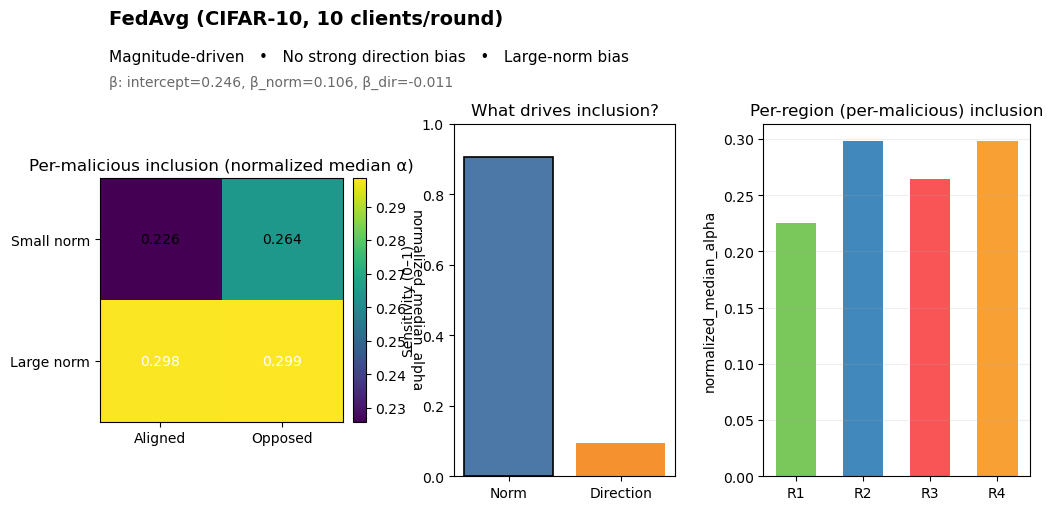

In [2]:
plot_agg_pref(
    json_path="/home2/liyang/GitHub/Mirage/Mirage/savedloggers/_Aug.15_22.21.22_fedavg/agg_pref_summary.json",
    title="FedAvg (CIFAR-10, 10 clients/round)",
    show_total_alpha=False,      # set True if you want total α markers also
    save_path=None               # or "pref_viz.png"
)